In [6]:
import pandas as pd

df = pd.read_csv('../data/phishing_url_dataset_raw.csv')
df.shape

# Rebuild numeric features and apply S01-02 feature selection
df_numeric = df.select_dtypes(include='number')
df_numeric = df_numeric.drop(['DomainTitleMatchScore', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfEqualsInURL', 'HasObfuscation'], axis=1)

# Split the dataset into inputs (X) and (y), then divide both into 80% training set and 20% test set, while preserving same ratio (phishing vs legitimate)
X = df_numeric.drop('label', axis=1)
y = df_numeric['label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Train the final model on the full training set (same as S1-03)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [7]:
from sklearn.metrics import classification_report

# Generate precision, recall, and F1 score per class - more informative than raw accuracy  
print(classification_report(y_test, y_pred, target_names=['Phishing', 'Legitimate']))

              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



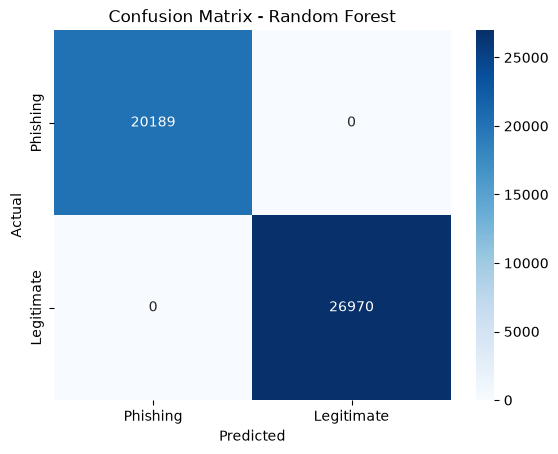

In [11]:
# Imports
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize exactly which predictions were correct/incorrect, by class
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Legitimate'], yticklabels=['Phishing', 'Legitimate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')                                                                                                       
plt.title('Confusion Matrix - Random Forest')
plt.show()                                                                                                   

In [10]:
# Get model's predicted probability that each test URL is legitimate, score how well the probabilities rank legitimate URLs
from sklearn.metrics import roc_auc_score

y_proba = rf.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

ROC-AUC: 1.0000


In [14]:
# Train an XGBoost model on training data, generate predictions on the test set, then print precision, recall, and F1 score for both classes
from xgboost import XGBClassifier
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb, target_names=['Phishing', 'Legitimate']))

              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
  Legitimate       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



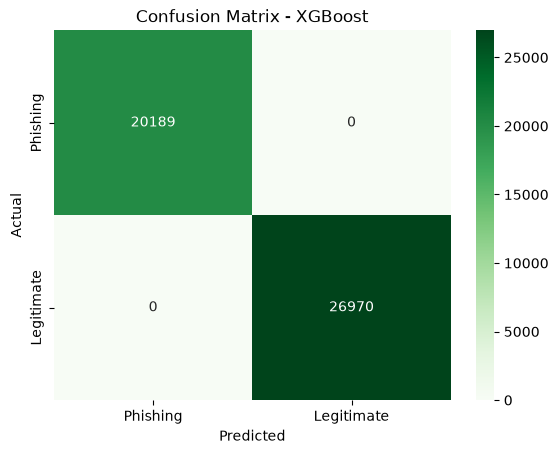

XGBoost ROC-AUC: 1.0000


In [16]:
# Draw conclusion matrix for XGBoost's predictions, then caluclate and print how well XGBoost seperates phishing from legitimate URLS across all probabability treshold (ROC-AUC)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', xticklabels=['Phishing', 'Legitimate'], yticklabels=['Phishing', 'Legitimate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()

y_proba_xgb = xgb.predict_proba(X_test)[:, 1]
print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")